# HFT Strategy

## Imports

In [88]:
# general
import pandas as pd
import numpy as np 
from datetime import datetime
# api 
import databento as db
# eda 
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
import lob_graphics 
# custom modules 
from mbo_schema_to_dataframe import import_data
import build_limit_order_book as build_lob 
import limit_order_book_metrics as lob_metrics 
import probability_model as prob_model
from high_frequency_returns import hft_returns 

## Data 

In [ ]:
# load data
paths = ['/DATA_PATH'] # change to your path
data = import_data(paths)

In [3]:
data[0].head()

,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
ts_recv,,,,,,,,,,,,,,
2025-07-22 08:00:00.000801028+00:00,2025-07-22 08:00:00.000634385+00:00,160,2,15144,A,A,628.25,100,0,24,130,166643,288486,SPY
2025-07-22 08:00:00.000873195+00:00,2025-07-22 08:00:00.000707476+00:00,160,2,15144,A,B,628.15,100,0,44,130,165719,288494,SPY
2025-07-22 08:00:00.016388808+00:00,2025-07-22 08:00:00.016223380+00:00,160,2,15144,A,B,626.24,300,0,3276,130,165428,289307,SPY
2025-07-22 08:00:00.016476866+00:00,2025-07-22 08:00:00.016310999+00:00,160,2,15144,A,A,636.24,300,0,3300,130,165867,289316,SPY
2025-07-22 08:00:00.054554003+00:00,2025-07-22 08:00:00.054388926+00:00,160,2,15144,C,A,628.25,100,0,24,130,165077,290114,SPY


approx 16 hours of order book data 

In [5]:
start_time = data[0].index[0]
end_time = data[0].index[-1]
total_time = end_time - start_time
print(f'total_time: {total_time} \nend_time: {end_time} \nstart time: {start_time}') 

total_time: 0 days 15:59:59.000897615 
end_time: 2025-07-22 23:59:59.001698643+00:00 
start time: 2025-07-22 08:00:00.000801028+00:00


## Building Limit Order Book 

In [6]:
#obs = 1000
#mini_batch_data = data[0].iloc[:obs,]
l3_to_lob = build_lob.lob(data[0])

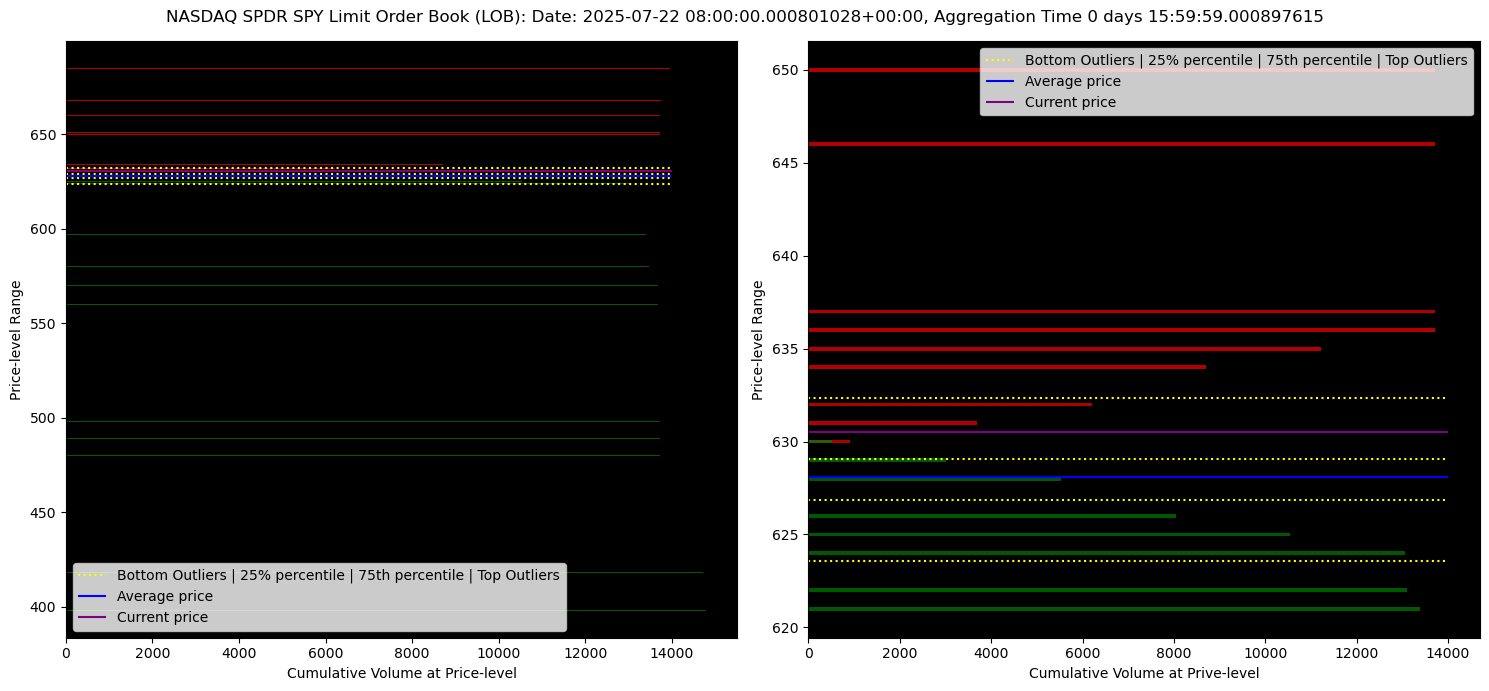

In [7]:
# spy demand/supply side of lob 
spy_price = data[0]['price']
book = l3_to_lob['lob']
book_demand = book['d']
book_supply = book['s']

# plot demand and supply liquidity 
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))
fig.suptitle(f'NASDAQ SPDR SPY Limit Order Book (LOB): Date: {data[0].index[0]}, Aggregation Time {total_time}')
ax1.set_facecolor('black')
ax1.set_ylabel('Price-level Range')
ax1.set_xlabel('Cumulative Volume at Price-level')
ax2.set_facecolor('black')
ax2.set_ylabel('Price-level Range')
ax2.set_xlabel('Cumulative Volume at Prive-level')

# first plot is global view
global_bids = lob_graphics.vis_lob_side(book_supply, 'red', bottom_book = 0, top_book = 1e5, axis = ax1)
global_asks = lob_graphics.vis_lob_side(book_demand, 'green', bottom_book = 0, top_book = 1e5, axis = ax1, side = 'B')
lob_graphics.price_from_data(spy_price.dropna(), max_freq = 14000, axis = ax1)

# second plot is local view
local_asks = lob_graphics.vis_lob_side(book_supply, 'red', bottom_book = 620, top_book = 650, axis = ax2)
local_bids = lob_graphics.vis_lob_side(book_demand, 'green', bottom_book = 620, top_book = 650 , axis = ax2, side = 'B')
lob_graphics.price_from_data(spy_price.dropna(), max_freq = 14000, axis = ax2)

fig.tight_layout();

more simply

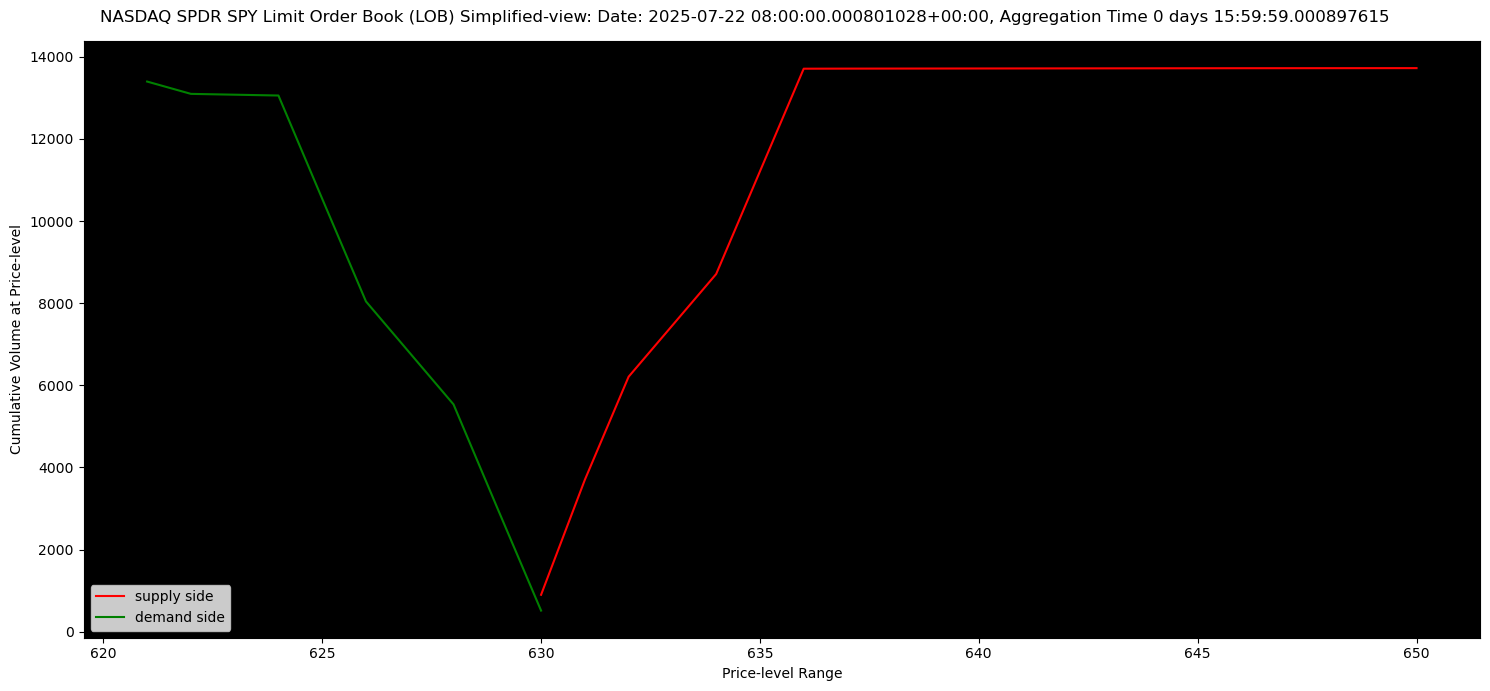

In [9]:
fig, ax1 = plt.subplots(nrows = 1, ncols = 1, figsize = (15, 7))
fig.suptitle(f'NASDAQ SPDR SPY Limit Order Book (LOB) Simplified-view: Date: {data[0].index[0]}, Aggregation Time {total_time}')
ax1.set_facecolor('black')

ax1.plot(local_asks.keys(), local_asks.values(), color = 'r', label = 'supply side')
ax1.plot(local_bids.keys(), local_bids.values(), color = 'g', label = 'demand side')
ax1.set_xlabel('Price-level Range')
ax1.set_ylabel('Cumulative Volume at Price-level')
ax1.legend()

fig.tight_layout();

check no arbitrage (highest bid is lower than lowest ask)

In [10]:
best_bid = max(book_demand.keys())
best_ask = min(book_supply.keys())

print(f'best ask: {best_ask} \nbest bid: {best_bid}')

best ask: 630 
best bid: 630


## Imbalance Analysis 

check balance of total final limit orders

In [11]:
demand_to_supply = len(book_demand) / len(book_supply) 
demand_to_supply # roughly the same number of orders on both sides of the book

2.4

visualise weighting bid and ask volume by volume conterbution

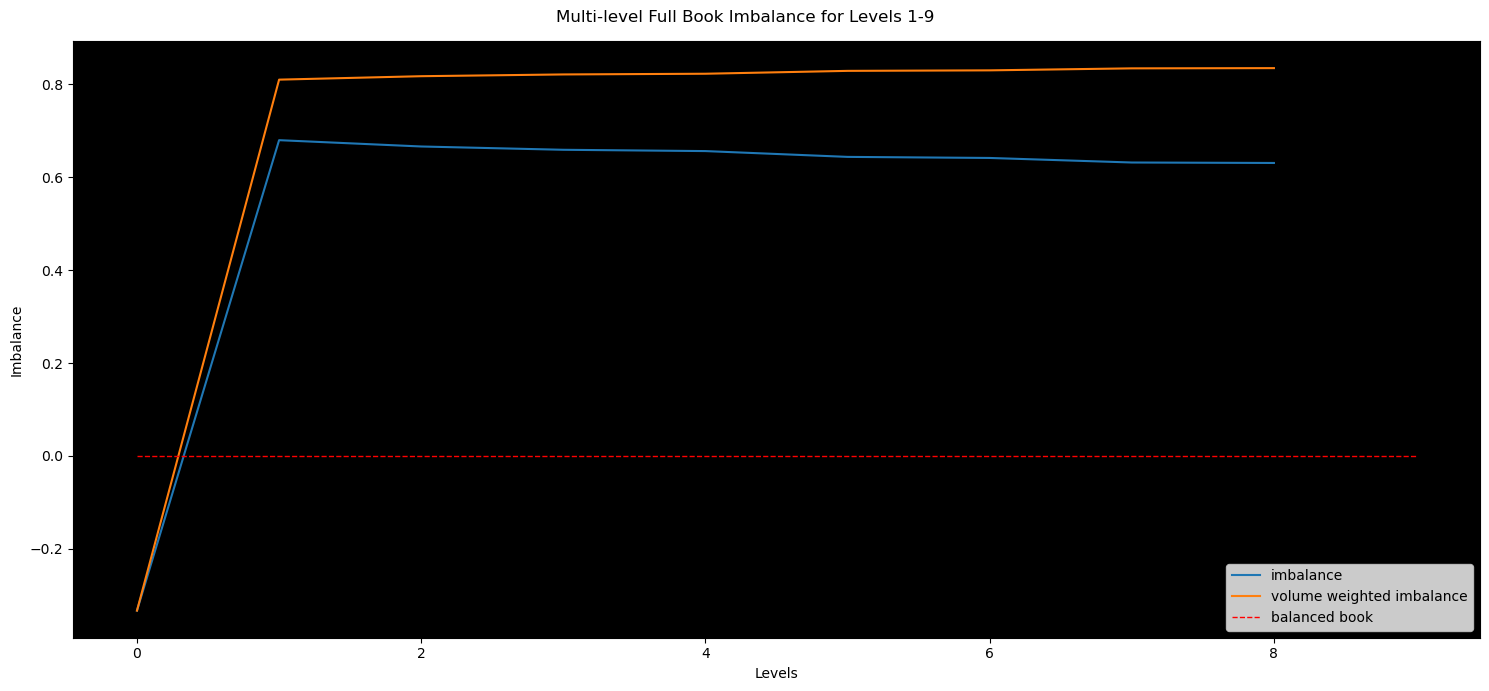

In [12]:
# imbalance
max_levels = 9
imb = lob_metrics.imbalance_wrapper(book = book, w_volume = False, max_levels=max_levels)
imb_wv = lob_metrics.imbalance_wrapper(book = book, w_volume = True, max_levels=max_levels)

# plots 
fig, (ax1) = plt.subplots(figsize = (15, 7))
fig.suptitle(f"Multi-level Full Book Imbalance for Levels 1-{max_levels}")
ax1.set_facecolor('black')

# plot n-level imbalance against n-level volume weighted imbalance
ax1.plot(imb, label = 'imbalance')
ax1.plot(imb_wv, label = 'volume weighted imbalance')
ax1.set_ylabel('Imbalance')
ax1.set_xlabel('Levels')

# equilibrium 
ax1.hlines(0, xmin = 0, xmax = max_levels, color = 'r', linestyles = '--', linewidth = 1, label = 'balanced book')

ax1.legend()
fig.tight_layout();

## Limit Order Book Snapshots 

In [8]:
# get snapshots
lob_res = build_lob.lob(mbo_schema = data[0], snapshots = True)

time = lob_res['lob_snapshot_times']
lob_snapshots = lob_res['lob_snapshots']
lob_snapshot_order_count = lob_res['lob_snapshot_order_count']
price = lob_res['micro_price']
book = lob_res['book']

## EDA

In [4]:
print('number of snapshots:', len(lob_snapshots), 
      '| number of times:', len(time), 
      '| number of prices:', len(price))

# choose order book and get imbalance in book
lob_1 = lob_snapshots[1823] # specifc order book 
imb_levels = 1
lob_1_imb = lob_metrics.get_imbalance(lob = lob_1, n_levels = imb_levels)

# plot 
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))
fig.suptitle(f'LOB Snapshot 1 @Time {time[2]}, {imb_levels} Level Imbalance {lob_1_imb :.2f}%')
ax1.set_facecolor('black')
ax1.set_ylabel('Price-level Range')
ax1.set_xlabel('Cumulative Volume at Price-level')

ax2.set_facecolor('black')
ax2.set_ylabel('Price-level Range')
ax2.set_xlabel('Cumulative Volume at Price-level')

lob_graphics.vis_lob_side(lob_sid = lob_1['s'], col = 'r', bottom_book = 0, top_book = 1e5, axis = ax1)
lob_graphics.vis_lob_side(lob_sid = lob_1['d'], col = 'g', bottom_book = 0, top_book = 1e5, axis = ax1, side = 'b')

lob_graphics.vis_lob_side(lob_sid = lob_1['s'], col = 'r', bottom_book = 600, top_book = 680, axis = ax2)
lob_graphics.vis_lob_side(lob_sid = lob_1['d'], col = 'g', bottom_book = 600, top_book = 680, axis = ax2, side = 'b')
fig.tight_layout();

NameError: name 'lob_snapshots' is not defined

### Animation 

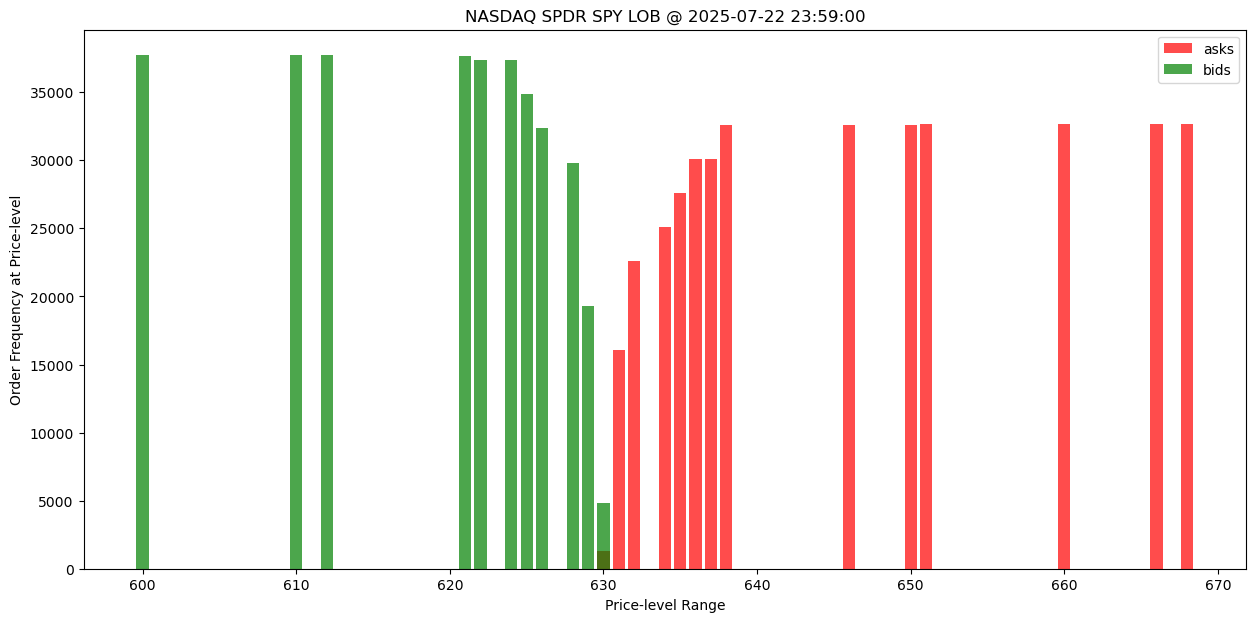

In [ ]:
def animate_lob(lob_snaps, times, x_min, x_max):
    fig, ax = plt.subplots(figsize = (15, 7))

    snaps = list(lob_snaps.keys())
    
    def update(i):
        ax.clear()
        snap = snaps[i]
        sell_dict = lob_graphics.format_lob(lob_snaps[snap]['s'], bottom_book = x_min, top_book = x_max, side = 's')
        buy_dict = lob_graphics.format_lob(lob_snaps[snap]['d'], bottom_book = x_min, top_book = x_max, side = 'b')
        # for bids 
        ys = list(sell_dict.keys())
        ws = list(sell_dict.values())
        ax.bar(ys, ws, color = 'r', alpha = 0.7, label = 'asks')  
        ys = list(buy_dict.keys())
        ws = list(buy_dict.values())
        # for asks 
        ax.bar(ys, ws, color = 'g', alpha = 0.7, label = 'bids')  
        # fig annot
        ax.set_xlabel('Price-level Range')
        ax.set_ylabel('Cumulative Volume at Price-level')
        ax.set_title(f'NASDAQ SPDR SPY LOB @ {times[i].strftime("%Y-%m-%d %H:%M:%S")}')
        fig.legend()
        return []

    ani = animation.FuncAnimation(fig = fig, func = update, frames = len(snaps), interval = 200, blit = False)
    return ani, frames 

#min_lob = {k: v for idx, (k, v) in enumerate(lob_snapshots.items()) if idx < 100}
ani, frames = animate_lob(lob_snapshots, times = time, x_min = 600, x_max = 680)
ani.save(filename='/Users/amjadsaidam/Desktop/Quant stuff /Limex Project /Code/lob_animation.gif', writer="pillow")
plt.show()

## Trade Size Quantiles 

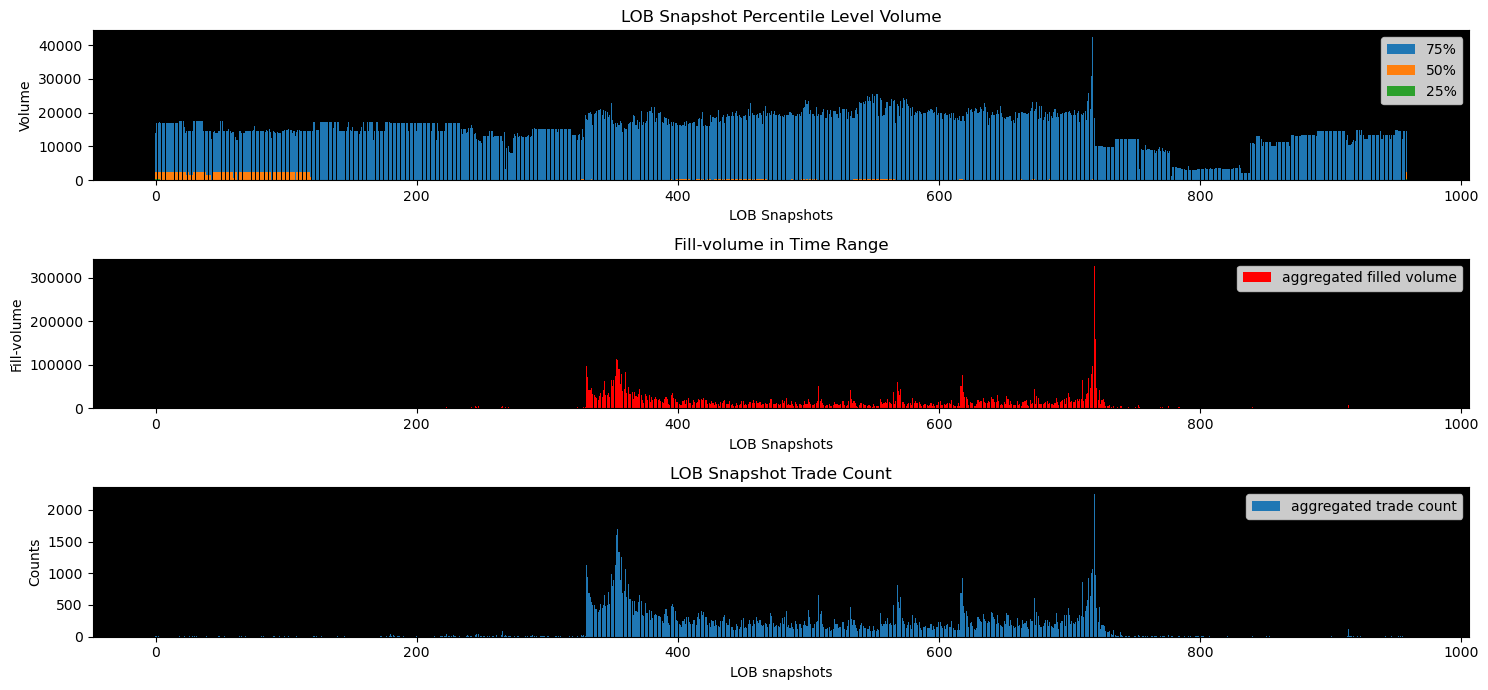

In [9]:
snapshot_metrics = lob_metrics.book_snapshot_metrics(lob_snapshots, lob_snapshot_order_count)
q_percentiles = snapshot_metrics.q_percentile_per_book()
nrow = list(range(959))
trades_fills = lob_res['trades_fills']

# plot
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 7))

# plot of trade percentiles
ax1.set_title(f'LOB Snapshot Percentile Level Volume')
ax1.set_facecolor('black')
ax1.bar(nrow, q_percentiles[:, 2], label = '75%')
ax1.bar(nrow, q_percentiles[:, 1], label = '50%')
ax1.bar(nrow, q_percentiles[:, 0], label = '25%')
ax1.set_xlabel('LOB Snapshots')
ax1.set_ylabel('Volume')
ax1.legend()

# fill volume in snapshot time
ax2.set_title('Fill-volume in Time Range')
ax2.set_facecolor('black')
ax2.bar(nrow, trades_fills['F'], color = 'red', label = 'aggregated filled volume')
ax2.set_xlabel('LOB Snapshots')
ax2.set_ylabel('Fill-volume')
ax2.legend()

# plot of trade count and number of fills
ax3.set_title('LOB Snapshot Trade Count')
ax3.set_facecolor('black')
ax3.bar(nrow, trades_fills['T'], label = 'aggregated trade count')
ax3.set_xlabel('LOB snapshots')
ax3.set_ylabel('Counts')
ax3.legend()

plt.tight_layout();

trade count and fills

## Probability Analysis

Get resting liquidity in bid/aks queue 

In [20]:
# for bids (assume 3rd order in book)
bid_l3 = book[0].bids
ask_l3 = book[0].asks

def queue_vol(trades, side: str = ('bids', 'asks'), pos: int = 3):
    """get queue liquidity for some position in queue on side of book"""
    q_v = 0
    q_p = 0
    levels = trades.keys()[::-1] if (side == 'bids') else trades.keys() # reverse sorted dict for bids to get TOB

    for level in levels: 
        current_level = trades[level].orders
        for tr in current_level:      
            if q_p <= pos:
                q_v += tr.size
                q_p += 1

    if q_p < pos:
        raise IndexError('queue position does not exist in book with maximum queue length', q_p)
    
    return q_v

# call
bid_queue_vol = queue_vol(bid_l3, side = 'bids', pos=0)
ask_queue_vol = queue_vol(bid_l3, side = 'asks', pos=0)

random variables for trade size, trade arrival, quote clearing trade size and time until quote clearing trade size 

In [11]:
orders = data[0].loc[:, 'size']
minq, maxq = min(orders), max(orders)

processes = prob_model.probability_model(mbo_schema = data[0], lob_snaps = lob_snapshots, lob_snaps_orders = lob_snapshot_order_count, time_unit='5', q_min = minq)

# model probability of number of orders
lambda_a = processes.frequnecy_ask_trades
lambda_b = processes.frequnecy_bid_trades
ks = np.arange(0, 100) # possion events P(X = k) for int k
pd_N_a = [processes.poisson_model(k_events = int(i)) for i in ks]
pd_N_b = [processes.poisson_model(side = 'b', k_events = int(i)) for i in ks]

# power law distribution of probability density of trade size 
qs = np.linspace(start = minq, stop = maxq, num = maxq)
pd_Q = [processes.power_series_pdf(q = int(i)) for i in qs]
cdf_Q = [processes.power_series_cdf(q = i) for i in qs]
ccdf_Q = [1 - processes.power_series_cdf(q = i) for i in qs]

# distribution of quote clearning trades in unit time t (v = liquidity in queue)
last_lob = lob_snapshots[sorted(lob_snapshots)[-1]] # last (curret) snapshot
ti_a = processes.lambda_trade_intensity(lob = last_lob, traders_per_t_side = lambda_a, v_custom = ask_queue_vol)
ti_b = processes.lambda_trade_intensity(lob = last_lob, traders_per_t_side = lambda_b, v_custom = bid_queue_vol)
pd_Nw_a = [processes._poisson_pdf(ti_a, k_events = int(i)) for i in ks]
pd_Nw_b = [processes._poisson_pdf(ti_b, k_events = int(i)) for i in ks]

# exponential distribution for time, delta unit time t, between quote clearning clearning trades (delta time = 1 -> time until first quote clearing trade)
delta_ts = np.linspace(start = 0, stop = 1, num = 100)
pd_wait_Nw1_a = [processes.exponential_cdf(trade_intenisty = lambda_a, delta_t = t) for t in delta_ts]
pd_wait_Nw1_b = [processes.exponential_cdf(trade_intenisty = lambda_b, delta_t = t) for t in delta_ts]

plot poisson probability denisty for different number of orders for both demand and supply side of book

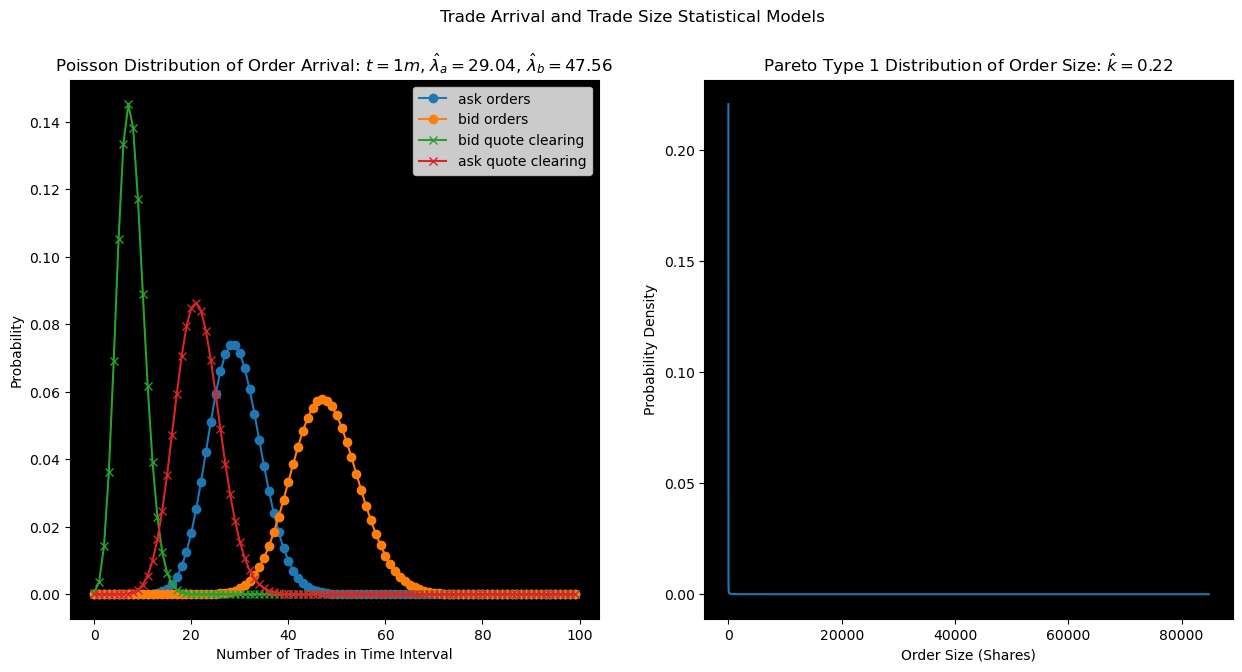

In [12]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))
fig.suptitle('Trade Arrival and Trade Size Statistical Models')

# poisson porcesses for trade size
ax1.set_title(r'Poisson Distribution of Order Arrival: $t=1m$, $\hat{\lambda}_a=29.04$, $\hat{\lambda}_b=47.56$')
ax1.set_facecolor('black')
ax1.plot(pd_N_a, label = 'ask orders', marker = 'o')
ax1.plot(pd_N_b, label = 'bid orders', marker = 'o')
ax1.plot(pd_Nw_b, label = 'bid quote clearing', marker = 'x')
ax1.plot(pd_Nw_a, label = 'ask quote clearing', marker = 'x')
ax1.set_ylabel('Probability')
ax1.set_xlabel('Number of Trades in Time Interval')
ax1.legend()

# power law;
ax2.set_title(r'Pareto Type 1 Distribution of Order Size: $\hat{k}=$' + f'{round(processes.alpha, 2)}')
ax2.set_facecolor('black')
ax2.plot(pd_Q)
ax2.set_ylabel('Probability Density')
ax2.set_xlabel('Order Size (Shares)')

fig.get_tightbbox();

pareto CDF, pareto Complement CDF exponential distribution

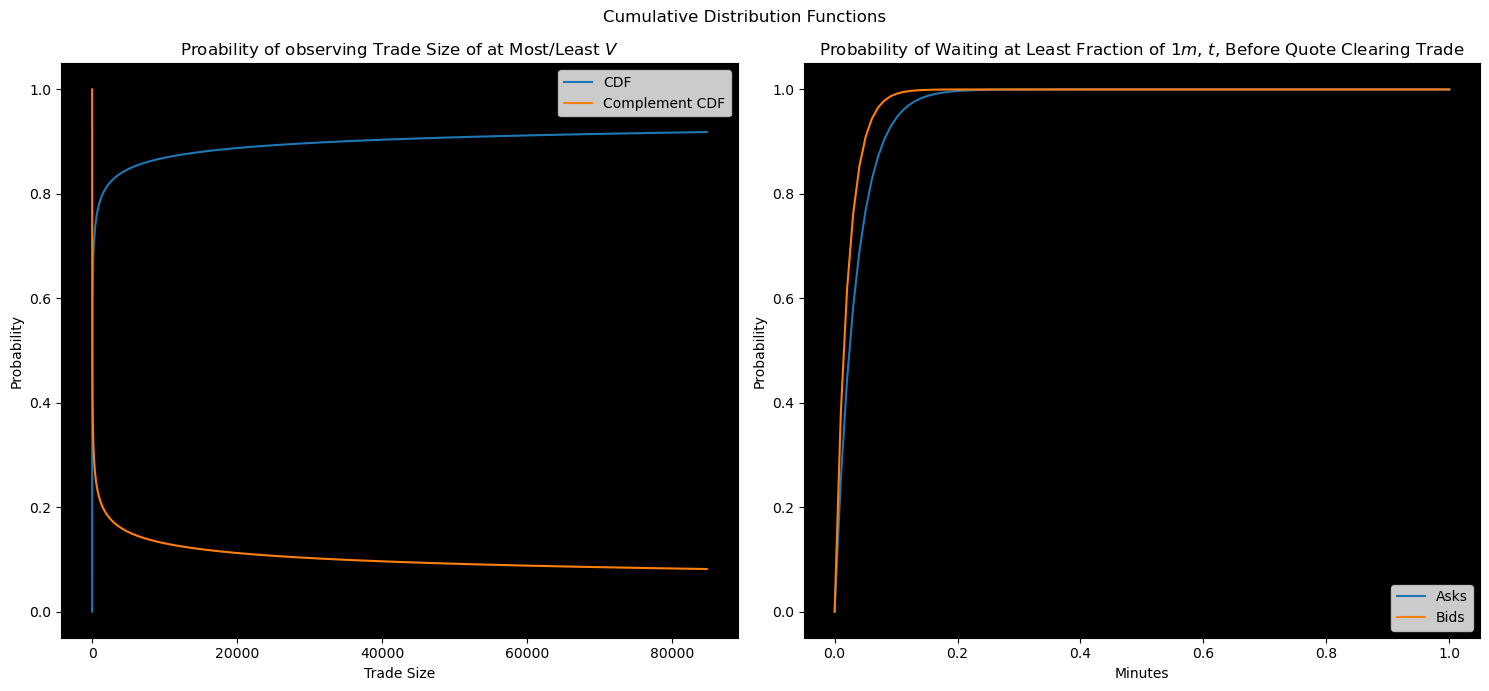

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))
fig.suptitle('Cumulative Distribution Functions')

# pareto cumulative distribution function and pareto complement distribution function
ax1.set_title(r'Proability of observing Trade Size of at Most/Least $V$')
ax1.set_facecolor('black')
ax1.plot(cdf_Q, label = 'CDF')
ax1.plot(ccdf_Q, label = 'Complement CDF')
ax1.set_xlabel('Trade Size')
ax1.set_ylabel('Probability')
ax1.legend()

# exponential distribution 
ax2.set_title(r'Probability of Waiting at Least Fraction of $1m$, $t$, Before Quote Clearing Trade')
ax2.set_facecolor('black')
ax2.plot(delta_ts, pd_wait_Nw1_a, label = 'Asks')
ax2.plot(delta_ts, pd_wait_Nw1_b, label = 'Bids')
ax2.set_xlabel('Minutes')
ax2.set_ylabel('Probability')
ax2.legend()


plt.tight_layout();

quote clearing trade are more likley on the bid side 

## Trading Strategy

In [46]:
def strategy_signals(lob_sz_snaps, lob_ct_snaps, mbo):
    assert len(lob_sz_snaps) == len(lob_ct_snaps)
    
    signals = []
    lambda_as = []
    lambda_bs = []
    model = prob_model.probability_model(mbo, lob_sz_snaps, lob_ct_snaps, time_unit='5')

    for snap, t in enumerate(lob_sz_snaps.keys()): 
        # get lobs
        lob_sz = lob_sz_snaps.get(t)
        lob_ct = lob_ct_snaps.get(t)

        # get volumes 
        bid_snap_t = book[snap].bids 
        ask_snap_t = book[snap].asks
        v_q_bids = queue_vol(bid_snap_t, side = 'bids', pos = 2)
        v_q_asks = queue_vol(ask_snap_t, side = 'asks', pos = 2)
    
        # get trade intensity 
        lambda_a = model.lambda_trade_intensity(lob_sz, traders_per_t_side = model.frequnecy_ask_trades, v_custom = v_q_bids)
        lambda_b = model.lambda_trade_intensity(lob_ct, traders_per_t_side = model.frequnecy_bid_trades, v_custom = v_q_asks)
        lambda_as.append(lambda_a)
        lambda_bs.append(lambda_b)

        # exponential wait time 
        wait_a = model.exponential_cdf(lambda_a, delta_t = 1)
        wait_b = model.exponential_cdf(lambda_b, delta_t = 1)

        # get signals
        sig = np.sign(wait_a - wait_b) # take order on side with highest probability of being filled
        signals.append(int(sig))
        
    return signals, lambda_as, lambda_bs

signals, las, lbs = strategy_signals(lob_sz_snaps = lob_snapshots, lob_ct_snaps = lob_snapshot_order_count, mbo = data[0])

## Backtest

In [47]:
# asset returns
micro_px = pd.Series(price)
micro_px_ft = micro_px.shift(1).dropna()
micro_rt = np.log(micro_px/micro_px_ft).fillna(0)

# benchmark returns
bench = hft_returns(returns = micro_rt, price = micro_px, position = pd.Series(signals), bnh = True) 
# strategy returns
strat = hft_returns(returns = micro_rt, price = micro_px, position = pd.Series(signals)) 
# strategy with fees 
scale_factor = 1/1e3 # unit fee
nyse_hft_fees = 3*scale_factor # units
strat_f = hft_returns(returns = micro_rt, price = micro_px, position = pd.Series(signals), dollar_fee = nyse_hft_fees) 

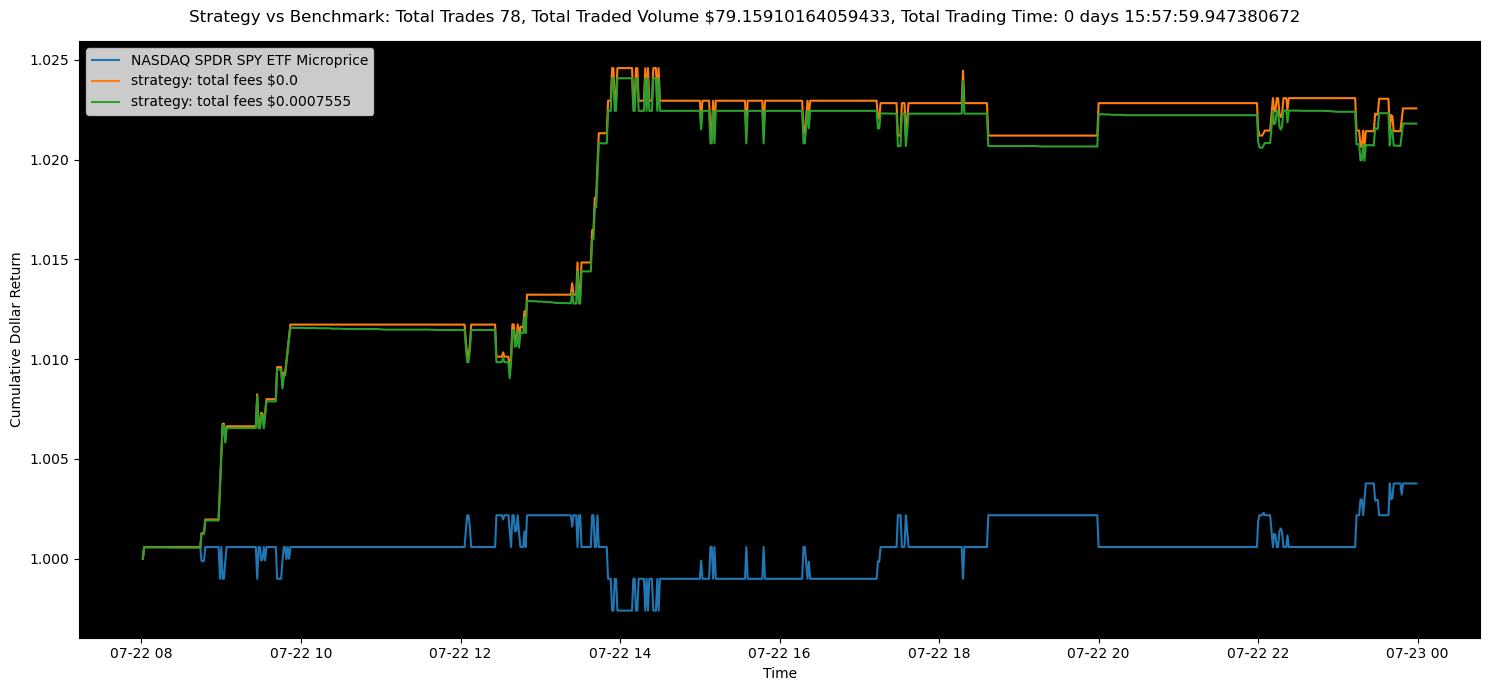

In [48]:
bench_rt = bench['equity']
strat_rt = strat['equity']
strat_rt_fee = strat_f['equity']

# plot performance
fig, (ax1) = plt.subplots(figsize = (15, 7))
fig.suptitle(f'Strategy vs Benchmark: Total Trades {strat['num_trades']}, Total Traded Volume ${strat['total_volume']}, Total Trading Time: {time[-1]-time[0]}')

# build plot 
ax1.set_facecolor('black')
ax1.plot(time, bench_rt, label = 'NASDAQ SPDR SPY ETF Microprice')
ax1.plot(time, strat_rt, label = f'strategy: total fees ${strat['total_fees']}')
ax1.plot(time, strat_rt_fee, label = f'strategy: total fees ${strat_f['total_fees']}')
ax1.set_xlabel('Time')
ax1.set_ylabel('Cumulative Dollar Return')
ax1.legend()

fig.tight_layout()

In [ ]:
alpha = np.array(strat['equity']).astype('float') - np.array(bench['equity']).astype('float')
np.where(alpha > 0) # minutes of overperformance 

(array([ 44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
         83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
         96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108,
        109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
        122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
        135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
        148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
        161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173,
        174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186,
        187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
        200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212,
        213, 214, 215, 216, 217, 218, 219, 220, 221

In [87]:
f_rt = (strat['equity'][-1] - 1) * 100
print('final return: {:.2f}%, alpha {:.2f}%'.format(f_rt, alpha[-1]*100))

final return: 2.26%, alpha 1.88%


## Appendix 

[1] - https://databento.com/docs/standards-and-conventions/common-fields-enums-types#rtype?historical=cpp&live=cpp&reference=python